In [244]:
import pandas as pd

# Data Understanding

## collect initial data

In [245]:
# Load the file
df = pd.read_csv('decoded_final_hydro_climate_data.csv')
df.head()

,Datetime,Hydro ID,mean,mean_yesterday,precip,precip_yesterday,target
0,2017-12-31,07FA004,2.271110,0.000000,0.0,0.0,0.153475
1,2018-01-01,07FA004,2.190741,2.271110,0.0,0.0,0.089377
2,2018-01-02,07FA004,2.219304,2.190741,0.0,0.0,0.108082
3,2018-01-03,07FA004,1.991847,2.219304,0.0,0.0,-0.072357
4,2018-01-04,07FA004,1.761454,1.991847,0.0,0.0,-0.258988


## describe data - meaning, type, basic stats etc
- The dataset contains 606,847 observations for key numeric variables (mean, mean_yesterday, precip, precip_yesterday, and target), with no missing values in these columns based on the count.
- mean and precip represent current-day climate conditions, while mean_yesterday and precip_yesterday are lagged (previous-day) features; target is the response variable for analysis/modeling.
- target is centered near zero (mean ≈ -0.015, median ≈ -0.035) with moderate spread (std ≈ 0.202), ranging from about -0.993 to 0.997.
- precip is strongly right-skewed (25th and 50th percentiles are 0, max is 246), indicating many dry periods and relatively fewer heavy-precipitation events; mean also shows a long right tail with extreme high values.

- Meaning（字段含义）：mean 和 precip 是当天气象变量，mean_yesterday、precip_yesterday 是对应的前一天值，target 是模型要预测/解释的响应变量。
- Type（数据类型）：这 5 列都是数值型连续变量（float），count 都是 606,847，说明这几列基本没有缺失值。
- Basic stats（基本统计）：target 的均值约 -0.0148、中位数 -0.0353，整体围绕 0 波动（std=0.202），范围约 [-0.993, 0.997]。
- precip 的中位数和 25% 分位都为 0，但最大值到 246，说明降水分布右偏明显：大多数时候降水小或为 0，少数时段有强降水。
- mean 的均值 (11.45) 远大于中位数 (1.54)，且最大值很高 (576.65)，同样显示长尾/极端值存在；昨天值与当天统计量接近，说明日际变化整体连续。


In [246]:
df.describe()

,mean,mean_yesterday,precip,precip_yesterday,target
count,606847.000000,606847.000000,606847.000000,606847.000000,606847.000000
mean,11.447702,11.439076,2.535151,2.534593,-0.014830
std,56.718763,56.705218,7.402791,7.398400,0.202021
min,-0.837236,-0.837236,0.000000,0.000000,-0.993422
25%,0.856284,0.853050,0.000000,0.000000,-0.152425
50%,1.538750,1.536375,0.000000,0.000000,-0.035252
75%,2.986805,2.983137,1.400000,1.400000,0.083507
max,576.647939,576.647939,246.000000,246.000000,0.997379


## Explore data - check visualization, summarizations, correlations, association rule, advanced statistics

### Visualization from grouped stats (`Hydro ID` and `Hydro ID × Season`)
Use these charts to compare station-level differences and seasonality.

In [247]:
# 1) Station-level summary table (Hydro ID)
station_stats = (
    df.groupby("Hydro ID")
      .agg(
          n=("target", "size"),
          target_mean=("target", "mean"),
          target_std=("target", "std"),
          target_q25=("target", lambda s: s.quantile(0.25)),
          target_q50=("target", "median"),
          target_q75=("target", lambda s: s.quantile(0.75)),
          mean_min=("mean", "min"),
          mean_max=("mean", "max"),
          precip_min=("precip", "min"),
          precip_max=("precip", "max"),
      )
      .reset_index()
)

station_stats.describe()

,n,target_mean,target_std,target_q25,target_q50,target_q75,mean_min,mean_max,precip_min,precip_max
count,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.0,232.000000
mean,2615.719828,-0.014486,0.183567,-0.154080,-0.048770,0.093059,11.126630,13.765312,0.0,77.717241
std,536.062447,0.036562,0.069484,0.076613,0.050201,0.066531,56.710087,58.481151,0.0,54.983454
min,128.000000,-0.168312,0.005120,-0.350026,-0.230570,-0.047660,-0.837236,0.398292,0.0,13.400000
25%,2725.000000,-0.030826,0.130142,-0.210469,-0.079139,0.035644,0.466391,2.264447,0.0,33.800000
50%,2831.500000,-0.012893,0.218080,-0.170188,-0.046797,0.088624,1.035568,3.433209,0.0,60.150000
75%,2850.000000,0.001463,0.236750,-0.096501,-0.016733,0.141961,2.177170,5.367651,0.0,113.350000
max,2851.000000,0.111651,0.280400,0.025392,0.120207,0.256707,546.982743,576.647939,0.0,246.000000


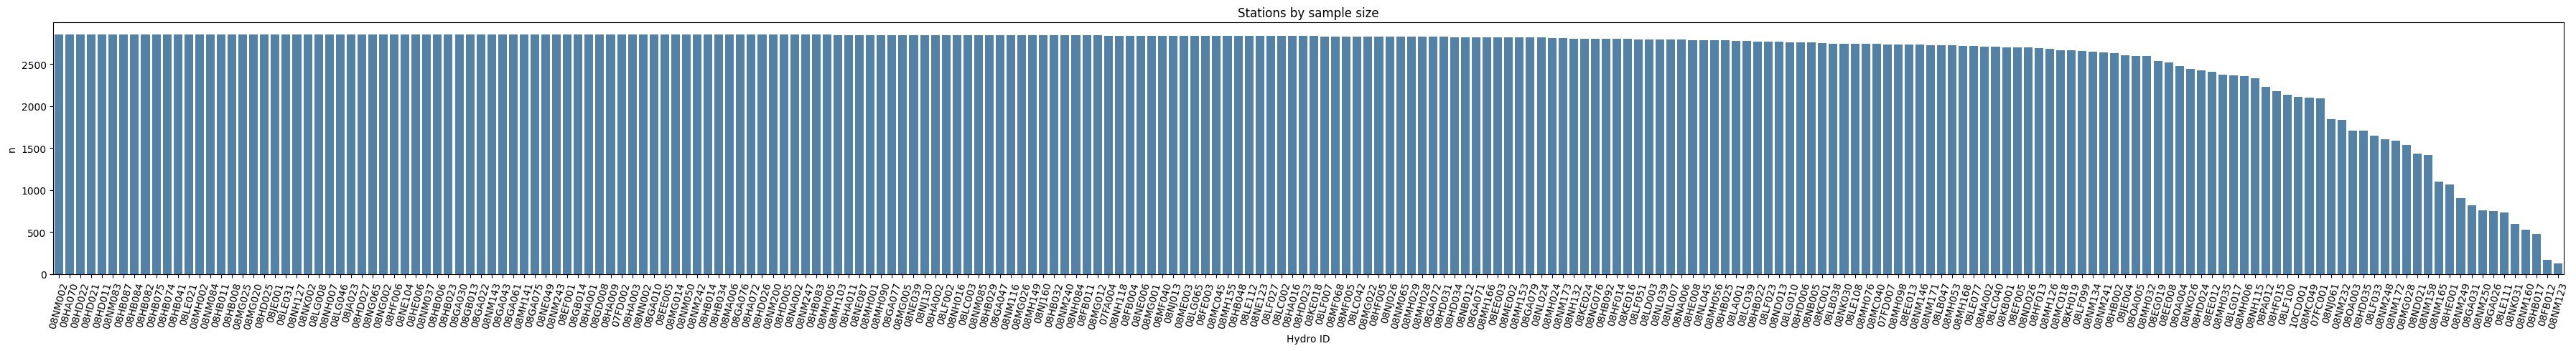

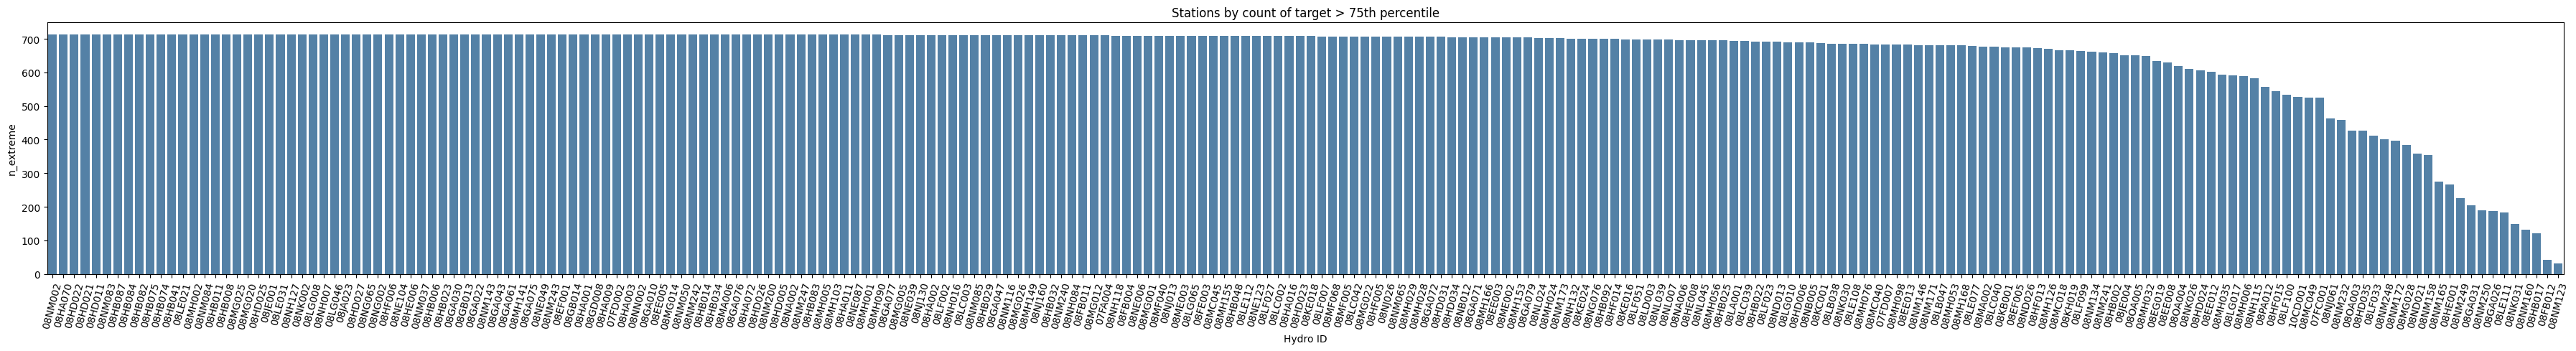

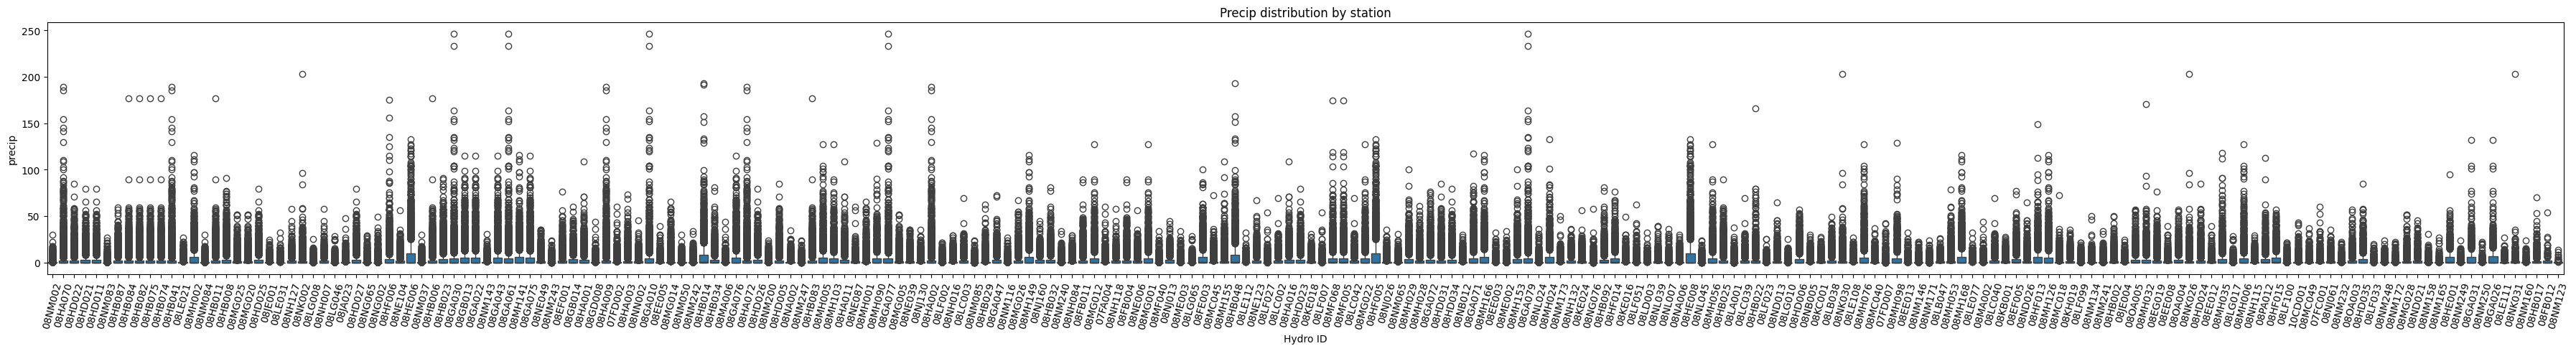

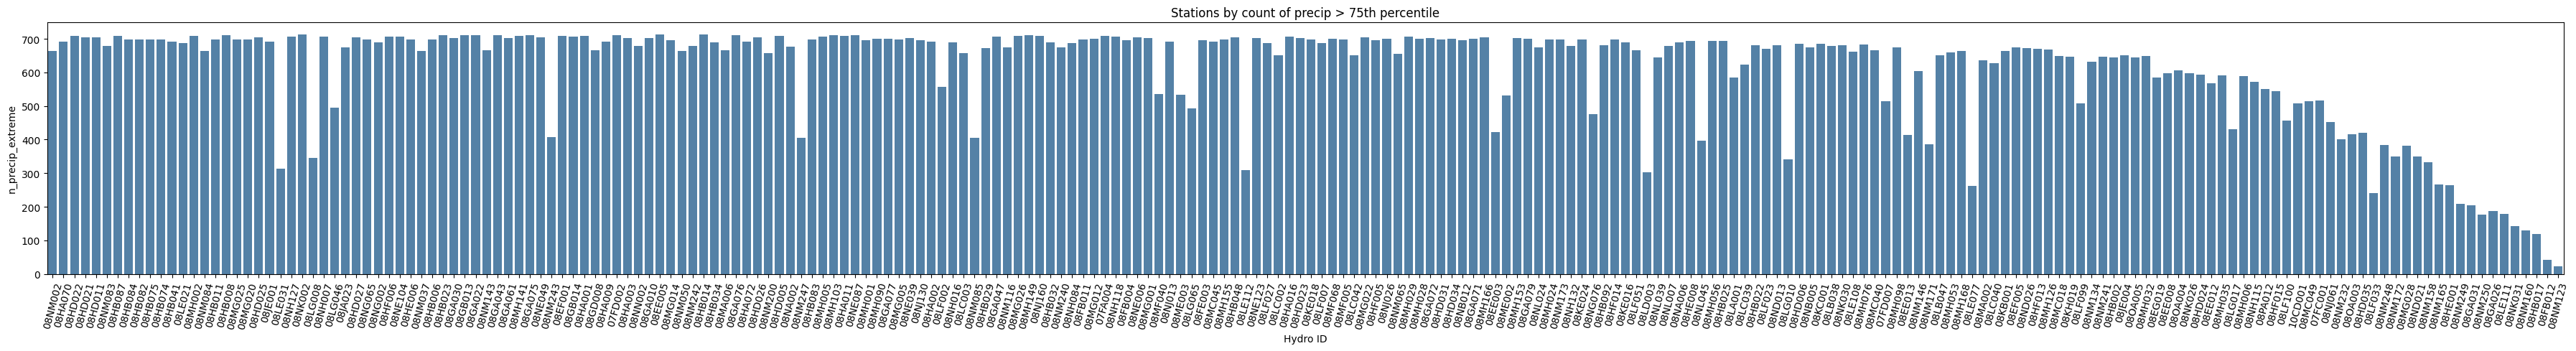

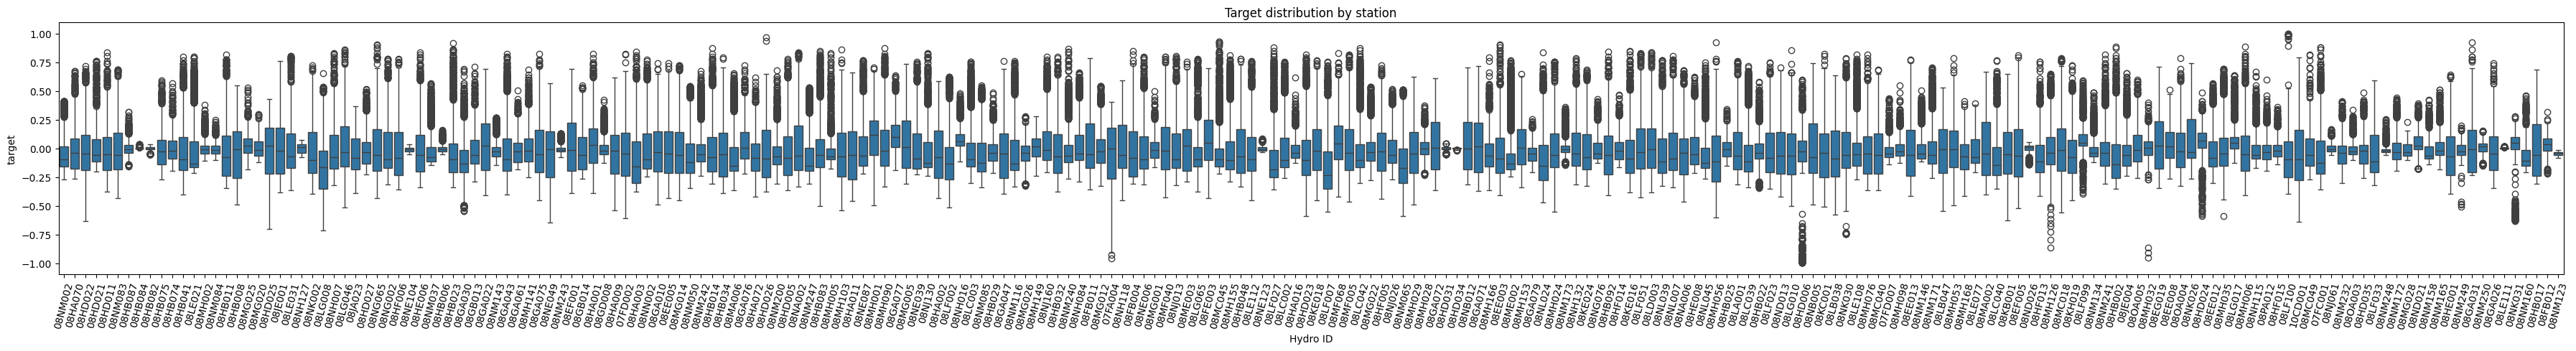

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

station_order = station_stats.sort_values("n", ascending=False)["Hydro ID"].tolist()

# 1) stations by sample size
plot_n = station_stats.sort_values("n", ascending=False)

plt.figure(figsize=(36, 5))
sns.barplot(data=plot_n, x="Hydro ID", y="n", order=station_order, color="steelblue")
plt.title("Stations by sample size")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# 2) target extreme counts
df_extreme = df.merge(
    station_stats[["Hydro ID", "target_q75"]],
    on="Hydro ID",
    how="left"
)
df_extreme = df_extreme[df_extreme["target"] > df_extreme["target_q75"]].copy()

plot_extreme = (
    df_extreme.groupby("Hydro ID")
    .size()
    .reset_index(name="n_extreme")
)

plt.figure(figsize=(36, 5))
sns.barplot(data=plot_extreme, x="Hydro ID", y="n_extreme", order=station_order, color="steelblue")
plt.title("Stations by count of target > 75th percentile")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# 3) target / precip boxplots
plt.figure(figsize=(36, 5))
sns.boxplot(data=df[df["Hydro ID"].isin(station_order)], x="Hydro ID", y="precip", order=station_order)
plt.title("Precip distribution by station")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# 4) precip extreme counts
station_precip_q75 = df.groupby("Hydro ID")["precip"].transform(lambda s: s.quantile(0.75))
df_precip_extreme = df[df["precip"] > station_precip_q75].copy()

plot_precip_extreme = (
    df_precip_extreme.groupby("Hydro ID")
    .size()
    .reset_index(name="n_precip_extreme")
)

plt.figure(figsize=(36, 5))
sns.barplot(data=plot_precip_extreme, x="Hydro ID", y="n_precip_extreme", order=station_order, color="steelblue")
plt.title("Stations by count of precip > 75th percentile")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


plt.figure(figsize=(36, 5))
sns.boxplot(data=df[df["Hydro ID"].isin(station_order)], x="Hydro ID", y="target", order=station_order)
plt.title("Target distribution by station")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

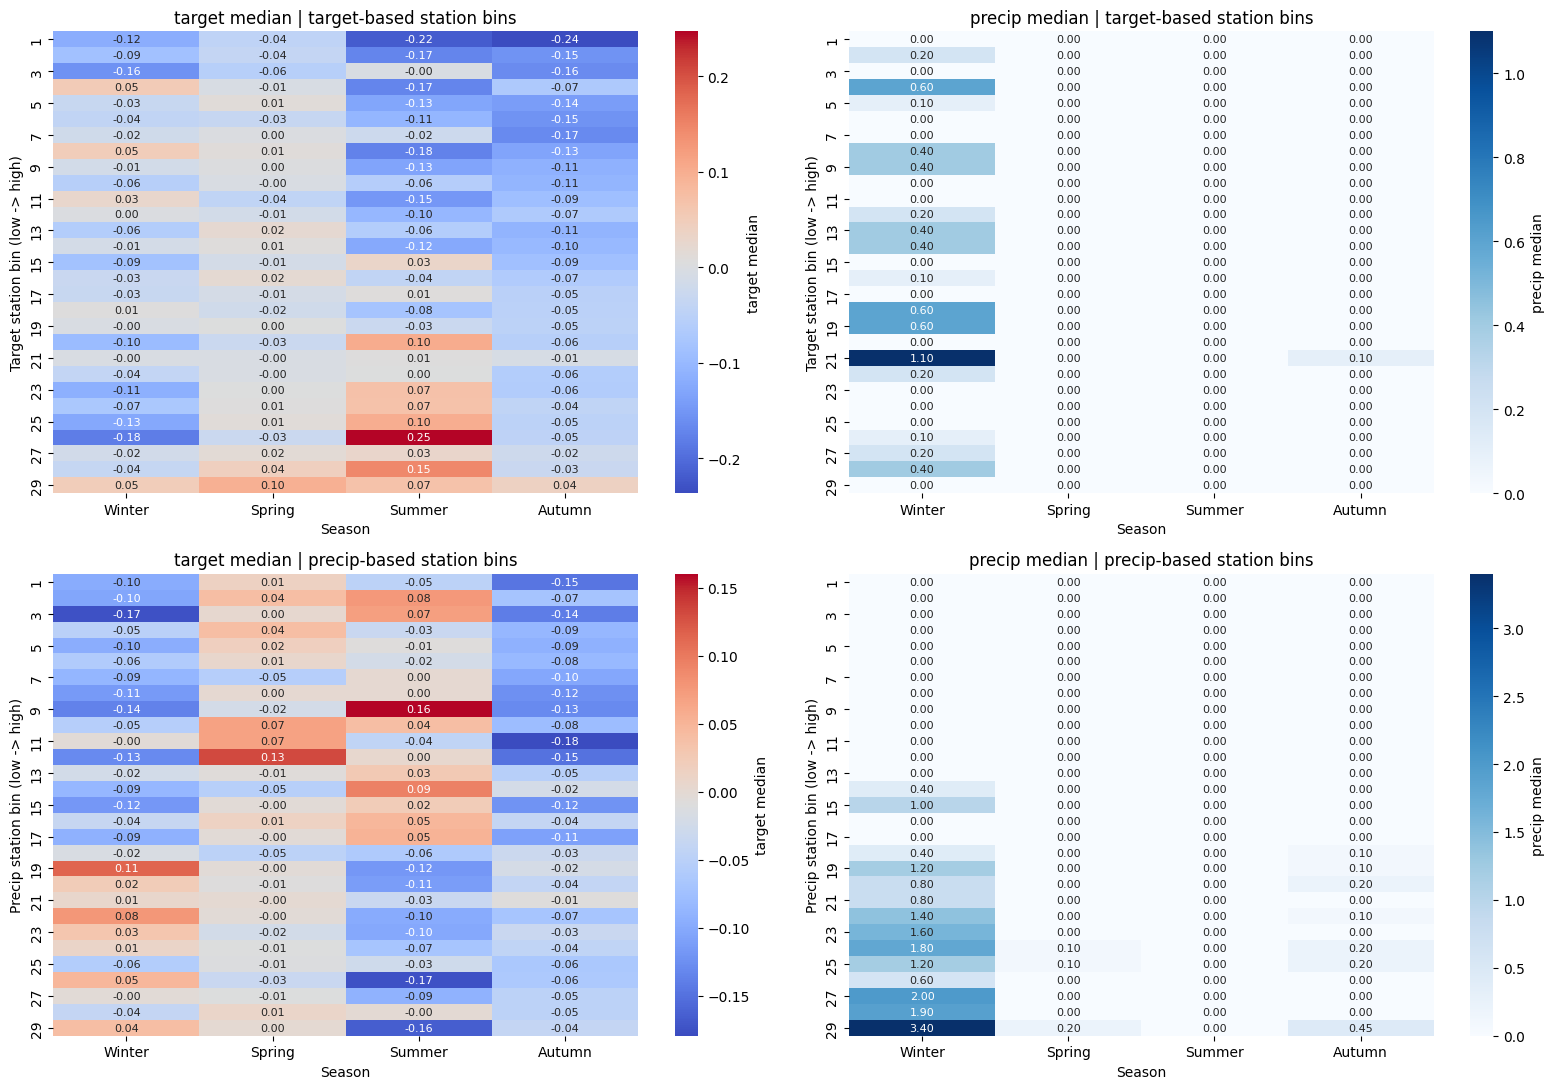

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1) Season ----------
if not pd.api.types.is_datetime64_any_dtype(df["Datetime"]):
    df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")

def to_season(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

order_season = ["Winter", "Spring", "Summer", "Autumn"]
df["Season"] = df["Datetime"].dt.month.map(to_season)

# ---------- 2) Station-level binning (29 bins, ~8 stations/bin) ----------
N_STATION_BINS = 29

# Use full data statistics (not q75-based) for station binning.
station_level = (
    df.groupby("Hydro ID", as_index=False)
      .agg(
          target_stat=("target", "mean"),   # can switch to "median"
          precip_stat=("precip", "mean"),   # can switch to "median"
      )
)

def station_equal_bins(s, n_bins=N_STATION_BINS):
    q = min(n_bins, s.notna().sum())
    return pd.qcut(s.rank(method="first"), q=q, labels=False) + 1

station_level["target_station_bin"] = station_equal_bins(station_level["target_stat"])
station_level["precip_station_bin"] = station_equal_bins(station_level["precip_stat"])

# Merge station bins back to row-level data.
df_bin = df.merge(
    station_level[["Hydro ID", "target_station_bin", "precip_station_bin"]],
    on="Hydro ID",
    how="left"
)

# ---------- 3) Bin × Season: VALUE level (median) ----------
# Target-based station bins -> seasonal median of target/precip
t_val = (
    df_bin.dropna(subset=["target_station_bin", "Season"])
          .groupby(["target_station_bin", "Season"], as_index=False)
          .agg(
              target_med=("target", "median"),
              precip_med=("precip", "median"),
              n=("target", "size")
          )
)

pivot_t_target = t_val.pivot(index="target_station_bin", columns="Season", values="target_med").reindex(columns=order_season)
pivot_t_precip = t_val.pivot(index="target_station_bin", columns="Season", values="precip_med").reindex(columns=order_season)

# Precip-based station bins -> seasonal median of target/precip
p_val = (
    df_bin.dropna(subset=["precip_station_bin", "Season"])
          .groupby(["precip_station_bin", "Season"], as_index=False)
          .agg(
              target_med=("target", "median"),
              precip_med=("precip", "median"),
              n=("target", "size")
          )
)

pivot_p_target = p_val.pivot(index="precip_station_bin", columns="Season", values="target_med").reindex(columns=order_season)
pivot_p_precip = p_val.pivot(index="precip_station_bin", columns="Season", values="precip_med").reindex(columns=order_season)

# ---------- 4) Plot: 2x2 (show actual values in cells) ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.heatmap(
    pivot_t_target,
    cmap="coolwarm",
    ax=axes[0, 0],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "target median"}
)
axes[0, 0].set_title("target median | target-based station bins")
axes[0, 0].set_xlabel("Season")
axes[0, 0].set_ylabel("Target station bin (low -> high)")

sns.heatmap(
    pivot_t_precip,
    cmap="Blues",
    ax=axes[0, 1],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "precip median"}
)
axes[0, 1].set_title("precip median | target-based station bins")
axes[0, 1].set_xlabel("Season")
axes[0, 1].set_ylabel("Target station bin (low -> high)")

sns.heatmap(
    pivot_p_target,
    cmap="coolwarm",
    ax=axes[1, 0],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "target median"}
)
axes[1, 0].set_title("target median | precip-based station bins")
axes[1, 0].set_xlabel("Season")
axes[1, 0].set_ylabel("Precip station bin (low -> high)")

sns.heatmap(
    pivot_p_precip,
    cmap="Blues",
    ax=axes[1, 1],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "precip median"}
)
axes[1, 1].set_title("precip median | precip-based station bins")
axes[1, 1].set_xlabel("Season")
axes[1, 1].set_ylabel("Precip station bin (low -> high)")

plt.tight_layout()
plt.show()

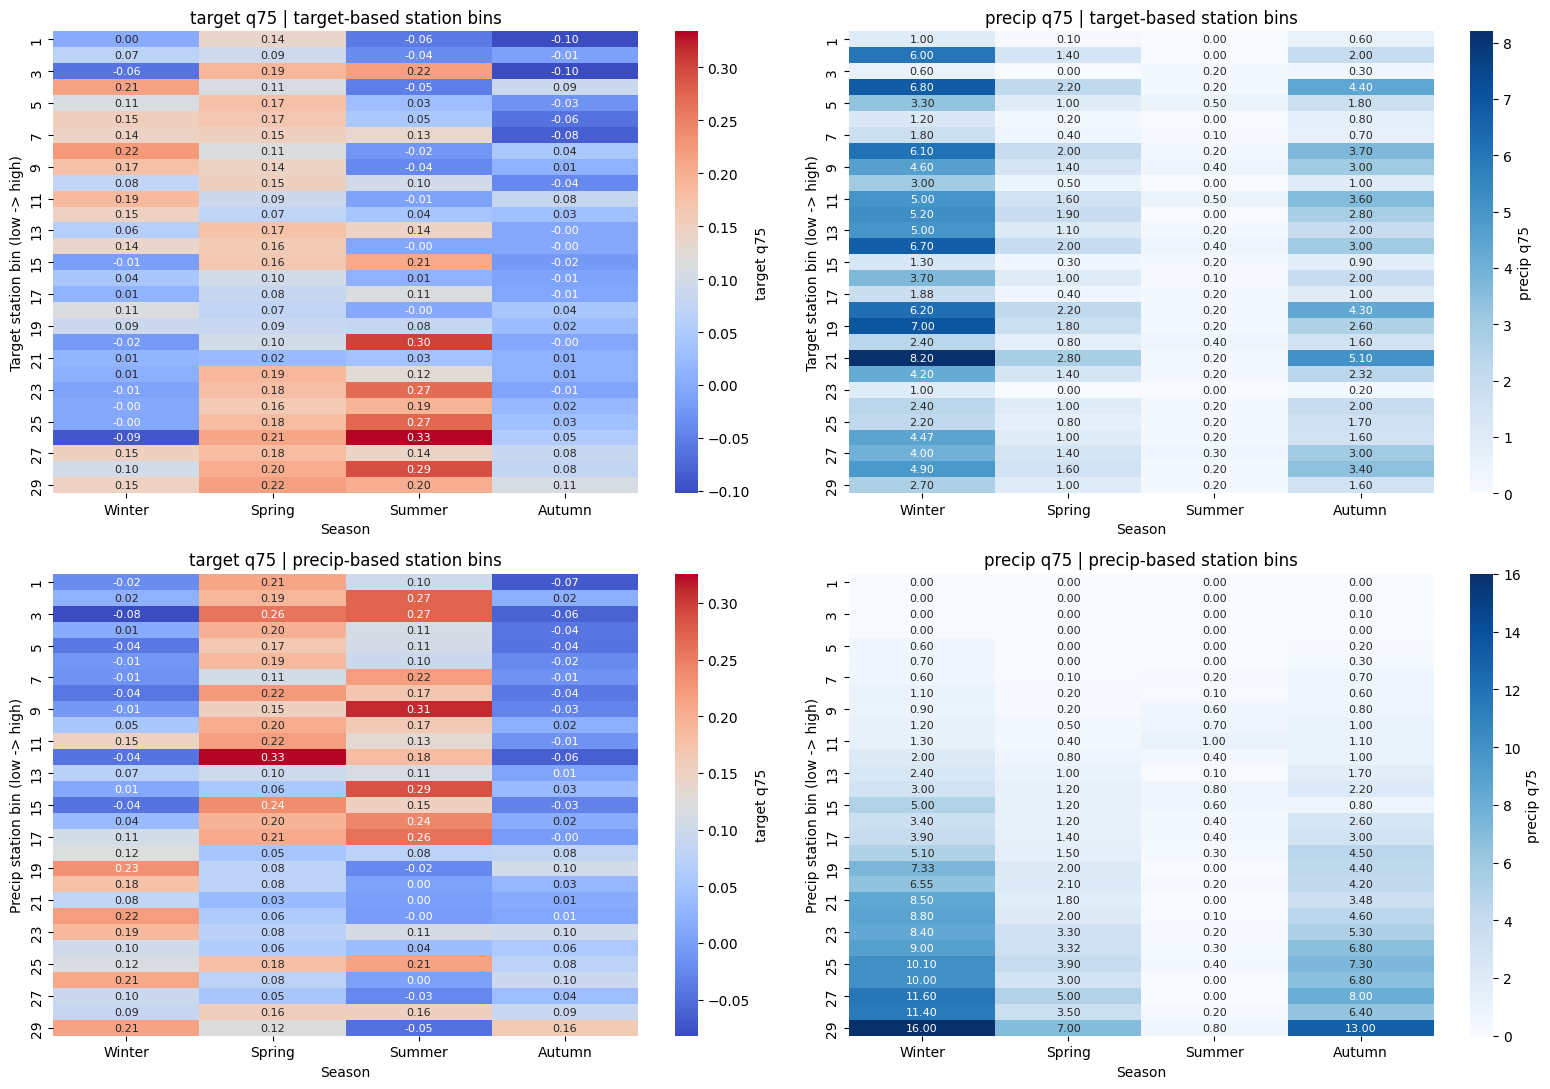

In [ ]:
# ---------- 5) Bin × Season: VALUE level (75th percentile) ----------
# Target-based station bins -> seasonal 75th percentile of target/precip
t_val = (
    df_bin.dropna(subset=["target_station_bin", "Season"])
          .groupby(["target_station_bin", "Season"], as_index=False)
          .agg(
              target_q75=("target", lambda s: s.quantile(0.75)),
              precip_q75=("precip", lambda s: s.quantile(0.75)),
              n=("target", "size")
          )
)

pivot_t_target = t_val.pivot(index="target_station_bin", columns="Season", values="target_q75").reindex(columns=order_season)
pivot_t_precip = t_val.pivot(index="target_station_bin", columns="Season", values="precip_q75").reindex(columns=order_season)

# Precip-based station bins -> seasonal 75th percentile of target/precip
p_val = (
    df_bin.dropna(subset=["precip_station_bin", "Season"])
          .groupby(["precip_station_bin", "Season"], as_index=False)
          .agg(
              target_q75=("target", lambda s: s.quantile(0.75)),
              precip_q75=("precip", lambda s: s.quantile(0.75)),
              n=("target", "size")
          )
)

pivot_p_target = p_val.pivot(index="precip_station_bin", columns="Season", values="target_q75").reindex(columns=order_season)
pivot_p_precip = p_val.pivot(index="precip_station_bin", columns="Season", values="precip_q75").reindex(columns=order_season)

# ---------- 6) Plot: 2x2 ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.heatmap(
    pivot_t_target,
    cmap="coolwarm",
    ax=axes[0, 0],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "target q75"}
)
axes[0, 0].set_title("target q75 | target-based station bins")
axes[0, 0].set_xlabel("Season")
axes[0, 0].set_ylabel("Target station bin (low -> high)")

sns.heatmap(
    pivot_t_precip,
    cmap="Blues",
    ax=axes[0, 1],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "precip q75"}
)
axes[0, 1].set_title("precip q75 | target-based station bins")
axes[0, 1].set_xlabel("Season")
axes[0, 1].set_ylabel("Target station bin (low -> high)")

sns.heatmap(
    pivot_p_target,
    cmap="coolwarm",
    ax=axes[1, 0],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "target q75"}
)
axes[1, 0].set_title("target q75 | precip-based station bins")
axes[1, 0].set_xlabel("Season")
axes[1, 0].set_ylabel("Precip station bin (low -> high)")

sns.heatmap(
    pivot_p_precip,
    cmap="Blues",
    ax=axes[1, 1],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "precip q75"}
)
axes[1, 1].set_title("precip q75 | precip-based station bins")
axes[1, 1].set_xlabel("Season")
axes[1, 1].set_ylabel("Precip station bin (low -> high)")

plt.tight_layout()
plt.show()

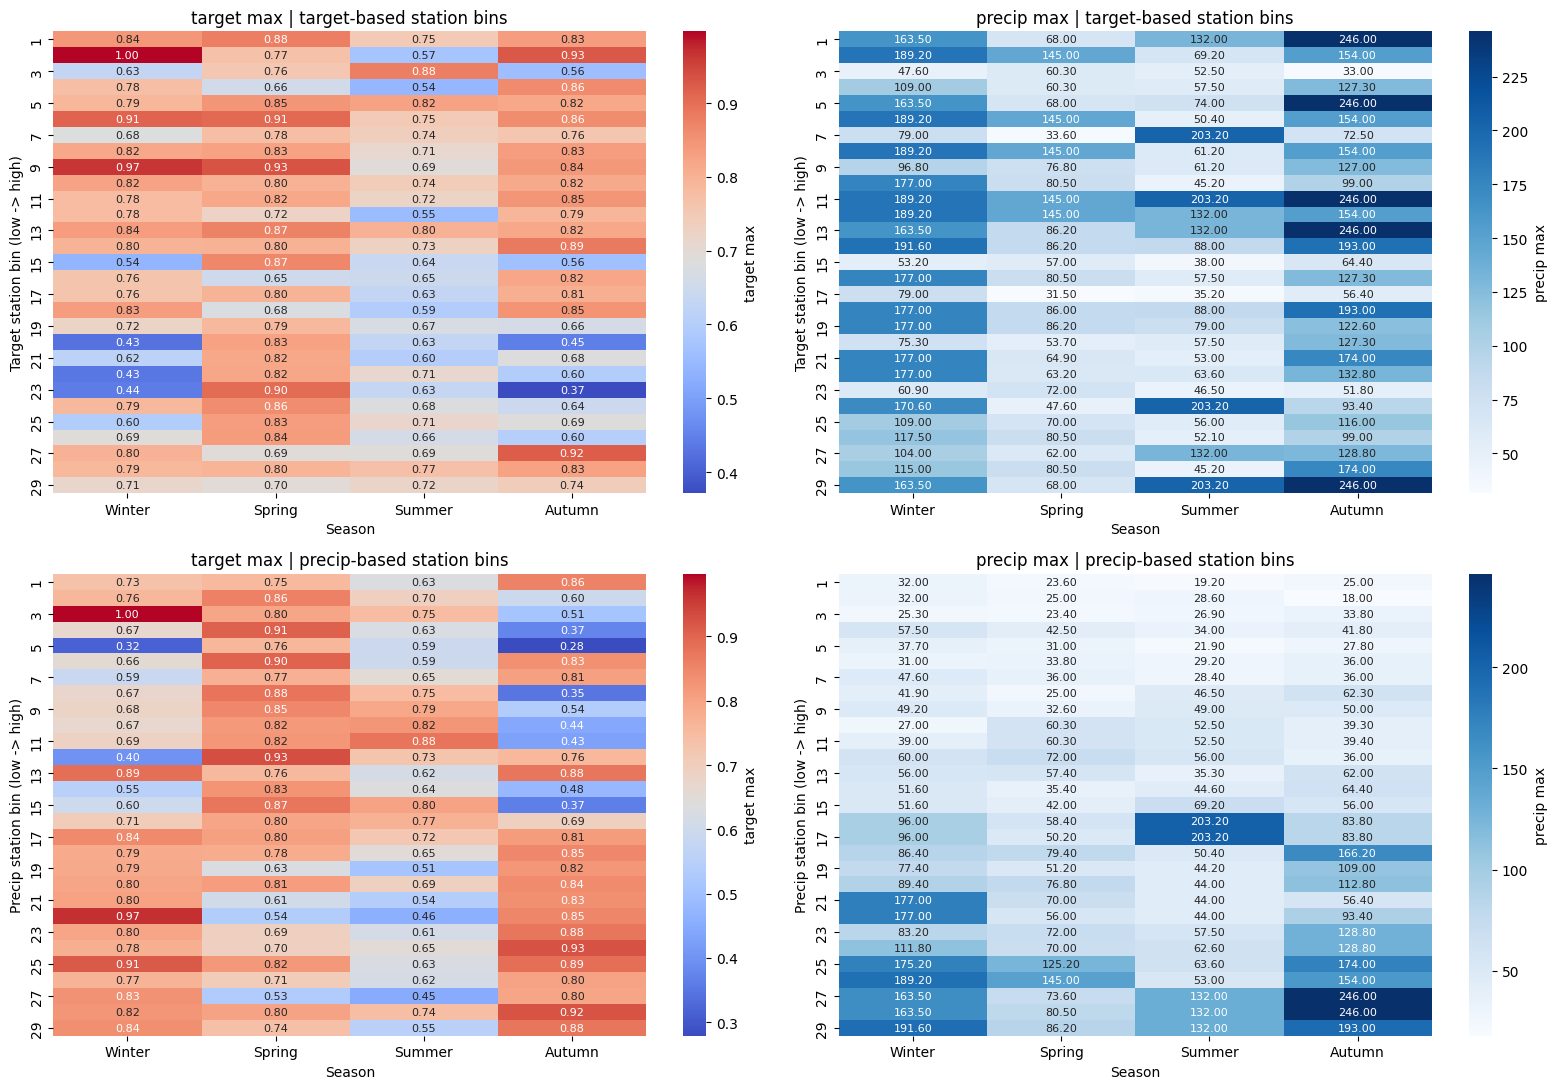

In [ ]:
# ---------- 7) Bin × Season: VALUE level (max) ----------
# Target-based station bins -> seasonal maximum of target/precip
t_val = (
    df_bin.dropna(subset=["target_station_bin", "Season"])
          .groupby(["target_station_bin", "Season"], as_index=False)
          .agg(
              target_max=("target", "max"),
              precip_max=("precip", "max"),
              n=("target", "size")
          )
)

pivot_t_target = t_val.pivot(index="target_station_bin", columns="Season", values="target_max").reindex(columns=order_season)
pivot_t_precip = t_val.pivot(index="target_station_bin", columns="Season", values="precip_max").reindex(columns=order_season)

# Precip-based station bins -> seasonal maximum of target/precip
p_val = (
    df_bin.dropna(subset=["precip_station_bin", "Season"])
          .groupby(["precip_station_bin", "Season"], as_index=False)
          .agg(
              target_max=("target", "max"),
              precip_max=("precip", "max"),
              n=("target", "size")
          )
)

pivot_p_target = p_val.pivot(index="precip_station_bin", columns="Season", values="target_max").reindex(columns=order_season)
pivot_p_precip = p_val.pivot(index="precip_station_bin", columns="Season", values="precip_max").reindex(columns=order_season)

# ---------- 8) Plot: 2x2 ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.heatmap(
    pivot_t_target,
    cmap="coolwarm",
    ax=axes[0, 0],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "target max"}
)
axes[0, 0].set_title("target max | target-based station bins")
axes[0, 0].set_xlabel("Season")
axes[0, 0].set_ylabel("Target station bin (low -> high)")

sns.heatmap(
    pivot_t_precip,
    cmap="Blues",
    ax=axes[0, 1],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "precip max"}
)
axes[0, 1].set_title("precip max | target-based station bins")
axes[0, 1].set_xlabel("Season")
axes[0, 1].set_ylabel("Target station bin (low -> high)")

sns.heatmap(
    pivot_p_target,
    cmap="coolwarm",
    ax=axes[1, 0],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "target max"}
)
axes[1, 0].set_title("target max | precip-based station bins")
axes[1, 0].set_xlabel("Season")
axes[1, 0].set_ylabel("Precip station bin (low -> high)")

sns.heatmap(
    pivot_p_precip,
    cmap="Blues",
    ax=axes[1, 1],
    annot=True, fmt=".2f",
    annot_kws={"size": 8},
    cbar_kws={"label": "precip max"}
)
axes[1, 1].set_title("precip max | precip-based station bins")
axes[1, 1].set_xlabel("Season")
axes[1, 1].set_ylabel("Precip station bin (low -> high)")

plt.tight_layout()
plt.show()

## Data Preparation

### select data and construct new columns
mean and mean_yesterday were excluded from feature selection because they are not independent predictors of the target.
The target is constructed from a standardized transformation of mean (z-score followed by tanh), so including mean (and its lagged version mean_yesterday) would introduce target leakage.
This would inflate apparent model performance without improving true generalization.
Therefore, the model uses precipitation-based variables (e.g., current precipitation and lagged/accumulated precipitation) as valid external predictors.

precip_yesterday was removed because it is highly redundant with a one-day lag of precip (shift(1)).
Our consistency check showed almost complete overlap (mean absolute difference ≈ 0.005; exact match rate ≈ 99.92%), indicating that precip_yesterday provides little additional information and may introduce unnecessary multicollinearity.

For retained predictors, both current precipitation and accumulated precipitation features show meaningful association with target.
In particular, the 7-day accumulation (precip_sum_7d) has the strongest and most stable correlation (Pearson and Spearman both around 0.20–0.25), suggesting a consistent linear/monotonic relationship with flood-intensity target.
Therefore, precipitation accumulation features—especially the 7-day window—were kept for modeling.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1) Sort ----------
df_corr = df.copy()
df_corr["Datetime"] = pd.to_datetime(df_corr["Datetime"], errors="coerce")
df_corr = df_corr.sort_values(["Hydro ID", "Datetime"])

# ---------- 2) Rolling accumulated precipitation ----------
# Use past precipitation only to avoid leakage from same-day precipitation.
for w in [3, 7, 14, 30]:
    df_corr[f"precip_sum_{w}d"] = (
        df_corr.groupby("Hydro ID")["precip"]
               .transform(lambda s: s.shift(1).rolling(w, min_periods=1).sum())
    )

# ---------- 2.1) Future targets (multi-horizon labels by station) ----------
for h in [1, 3, 7]:
    df_corr[f"target_t_plus_{h}d"] = (
        df_corr.groupby("Hydro ID")["target"].shift(-h)
    )

df_corr.head()

# ---------- 3) Overall correlation ----------
corr_cols = ["precip", "precip_sum_3d", "precip_sum_7d", "precip_sum_14d", "precip_sum_30d"]

rows = []
for col in corr_cols:
    tmp = df_corr[["target", col]].dropna()
    rows.append({
        "feature": col,
        "n": len(tmp),
        "pearson": tmp["target"].corr(tmp[col], method="pearson"),
        "spearman": tmp["target"].corr(tmp[col], method="spearman"),
    })

corr_table = pd.DataFrame(rows).sort_values("spearman", ascending=False)
corr_table

,feature,n,pearson,spearman
2,precip_sum_7d,606615,0.240960,0.199140
3,precip_sum_14d,606615,0.224949,0.198524
4,precip_sum_30d,606615,0.203279,0.189512
1,precip_sum_3d,606615,0.239891,0.184577
0,precip,606847,0.141155,0.126595


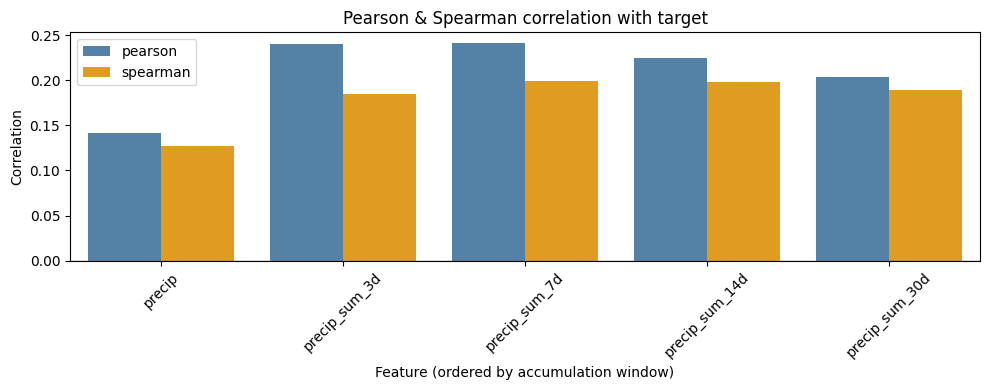

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

# 固定特征顺序：当天 -> 3d -> 7d -> 14d -> 30d
feature_order = ["precip", "precip_sum_3d", "precip_sum_7d", "precip_sum_14d", "precip_sum_30d"]

# 不按相关系数大小排序，按时间窗口排序
plot_df = corr_table.copy()
plot_df["feature"] = pd.Categorical(plot_df["feature"], categories=feature_order, ordered=True)
plot_df = plot_df.sort_values("feature")

# 宽表转长表：同时画 pearson/spearman
plot_long = plot_df.melt(
    id_vars=["feature"],
    value_vars=["pearson", "spearman"],
    var_name="metric",
    value_name="corr"
)

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_long, x="feature", y="corr", hue="metric", palette=["steelblue", "orange"])
plt.xticks(rotation=45)
plt.title("Pearson & Spearman correlation with target")
plt.xlabel("Feature (ordered by accumulation window)")
plt.ylabel("Correlation")
plt.axhline(0, color="gray", linewidth=1)
plt.legend(title="")
plt.tight_layout()
plt.show()

In [254]:
tmp = df.copy()
tmp["Datetime"] = pd.to_datetime(tmp["Datetime"], errors="coerce")
tmp = tmp.sort_values(["Hydro ID", "Datetime"])
tmp["precip_lag1_calc"] = tmp.groupby("Hydro ID")["precip"].shift(1)

check = (tmp["precip_yesterday"] - tmp["precip_lag1_calc"]).abs()
print("mean abs diff:", check.mean())
print("share exactly equal:", (check.fillna(0) == 0).mean())

mean abs diff: 0.004980094458594002
share exactly equal: 0.9992469271496769


In [255]:
selected_cols = [
    "Hydro ID",
    "Datetime",
    "target",
    "target_t_plus_1d",
    "target_t_plus_3d",
    "target_t_plus_7d",
    "precip",
    "precip_sum_3d",
    "precip_sum_7d",
    "precip_sum_14d",
    "precip_sum_30d",
]

df_selected = df_corr.loc[:, selected_cols].copy()
df_selected.head()

,Hydro ID,Datetime,target,target_t_plus_1d,target_t_plus_3d,target_t_plus_7d,precip,precip_sum_3d,precip_sum_7d,precip_sum_14d,precip_sum_30d
0,07FA004,2017-12-31,0.153475,0.089377,-0.072357,-0.032939,0.0,NaN,NaN,NaN,NaN
1,07FA004,2018-01-01,0.089377,0.108082,-0.258988,0.038023,0.0,0.0,0.0,0.0,0.0
2,07FA004,2018-01-02,0.108082,-0.072357,-0.155904,0.046719,0.0,0.0,0.0,0.0,0.0
3,07FA004,2018-01-03,-0.072357,-0.258988,-0.013828,0.028937,0.0,0.0,0.0,0.0,0.0
4,07FA004,2018-01-04,-0.258988,-0.155904,-0.032939,-0.232484,0.0,0.0,0.0,0.0,0.0


### clean data

For the lagged and rolling precipitation features, missing values occur only at the beginning of each Hydro ID series due to insufficient historical observations, so these NaNs were filled with 0 to indicate no prior accumulated precipitation.

In [256]:
lag_cols = ["precip_sum_3d", "precip_sum_7d", "precip_sum_14d", "precip_sum_30d"]
df_selected[lag_cols] = df_selected[lag_cols].fillna(0)
df_selected.head()

,Hydro ID,Datetime,target,target_t_plus_1d,target_t_plus_3d,target_t_plus_7d,precip,precip_sum_3d,precip_sum_7d,precip_sum_14d,precip_sum_30d
0,07FA004,2017-12-31,0.153475,0.089377,-0.072357,-0.032939,0.0,0.0,0.0,0.0,0.0
1,07FA004,2018-01-01,0.089377,0.108082,-0.258988,0.038023,0.0,0.0,0.0,0.0,0.0
2,07FA004,2018-01-02,0.108082,-0.072357,-0.155904,0.046719,0.0,0.0,0.0,0.0,0.0
3,07FA004,2018-01-03,-0.072357,-0.258988,-0.013828,0.028937,0.0,0.0,0.0,0.0,0.0
4,07FA004,2018-01-04,-0.258988,-0.155904,-0.032939,-0.232484,0.0,0.0,0.0,0.0,0.0


### construct data

In [ ]:
# 1) Keep time information in the base feature table
df_model = df_selected.copy()
df_model["Datetime"] = pd.to_datetime(df_model["Datetime"])
df_model = df_model.sort_values(["Hydro ID", "Datetime"])

# 2) Add time-derived features while preserving temporal continuity
df_model["month"] = df_model["Datetime"].dt.month
df_model["dayofyear"] = df_model["Datetime"].dt.dayofyear
df_model["season_code"] = df_model["month"].map({
    12: 1, 1: 1, 2: 1,      # Winter
    3: 2, 4: 2, 5: 2,       # Spring
    6: 3, 7: 3, 8: 3,       # Summer
    9: 4, 10: 4, 11: 4      # Autumn
})

df_model = df_model.drop(columns=["month"])

df_model = df_model.set_index("Datetime")

df_model

,Hydro ID,target,target_t_plus_1d,target_t_plus_3d,target_t_plus_7d,precip,precip_sum_3d,precip_sum_7d,precip_sum_14d,precip_sum_30d,dayofyear,season_code
Datetime,,,,,,,,,,,,
2017-12-31,07FA004,0.153475,0.089377,-0.072357,-0.032939,0.0,0.0,0.0,0.0,0.0,365,1
2018-01-01,07FA004,0.089377,0.108082,-0.258988,0.038023,0.0,0.0,0.0,0.0,0.0,1,1
2018-01-02,07FA004,0.108082,-0.072357,-0.155904,0.046719,0.0,0.0,0.0,0.0,0.0,2,1
2018-01-03,07FA004,-0.072357,-0.258988,-0.013828,0.028937,0.0,0.0,0.0,0.0,0.0,3,1
2018-01-04,07FA004,-0.258988,-0.155904,-0.032939,-0.232484,0.0,0.0,0.0,0.0,0.0,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-16,10CD001,-0.254008,-0.253890,-0.253654,NaN,0.3,0.0,0.0,6.8,8.0,289,4
2025-10-17,10CD001,-0.253890,-0.253772,-0.253537,NaN,0.0,0.3,0.3,7.1,8.3,290,4
2025-10-18,10CD001,-0.253772,-0.253654,NaN,NaN,0.0,0.3,0.3,7.1,8.3,291,4


### format data

In [258]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

year_days = np.where(df_model.index.is_leap_year, 366, 365)
df_model["doy_sin"] = np.sin(2 * np.pi * df_model["dayofyear"] / year_days)
df_model["doy_cos"] = np.cos(2 * np.pi * df_model["dayofyear"] / year_days)

# precip features: log1p -> MinMax[-1, 1]
rain_cols = ["precip", "precip_sum_3d", "precip_sum_7d", "precip_sum_14d", "precip_sum_30d"]
df_model[rain_cols] = np.log1p(df_model[rain_cols].clip(lower=0))

mm = MinMaxScaler(feature_range=(-1, 1))
df_model[rain_cols] = mm.fit_transform(df_model[rain_cols])

# one-hot
df_model = pd.get_dummies(
    df_model,
    columns=["Hydro ID", "season_code"],
    prefix=["HydroID", "season"],
    dtype=int
)

# drop redundant raw calendar ints
df_model = df_model.drop(columns=["dayofyear"])

df_model.head()

,target,target_t_plus_1d,target_t_plus_3d,target_t_plus_7d,precip,precip_sum_3d,precip_sum_7d,precip_sum_14d,precip_sum_30d,doy_sin,...,HydroID_08NN002,HydroID_08OA003,HydroID_08OA004,HydroID_08OA005,HydroID_08PA012,HydroID_10CD001,season_1,season_2,season_3,season_4
Datetime,,,,,,,,,,,,,,,,,,,,,
2017-12-31,0.153475,0.089377,-0.072357,-0.032939,-1.0,-1.0,-1.0,-1.0,-1.0,6.432491e-16,...,0,0,0,0,0,0,1,0,0,0
2018-01-01,0.089377,0.108082,-0.258988,0.038023,-1.0,-1.0,-1.0,-1.0,-1.0,1.721336e-02,...,0,0,0,0,0,0,1,0,0,0
2018-01-02,0.108082,-0.072357,-0.155904,0.046719,-1.0,-1.0,-1.0,-1.0,-1.0,3.442161e-02,...,0,0,0,0,0,0,1,0,0,0
2018-01-03,-0.072357,-0.258988,-0.013828,0.028937,-1.0,-1.0,-1.0,-1.0,-1.0,5.161967e-02,...,0,0,0,0,0,0,1,0,0,0
2018-01-04,-0.258988,-0.155904,-0.032939,-0.232484,-1.0,-1.0,-1.0,-1.0,-1.0,6.880243e-02,...,0,0,0,0,0,0,1,0,0,0


### correlation verification

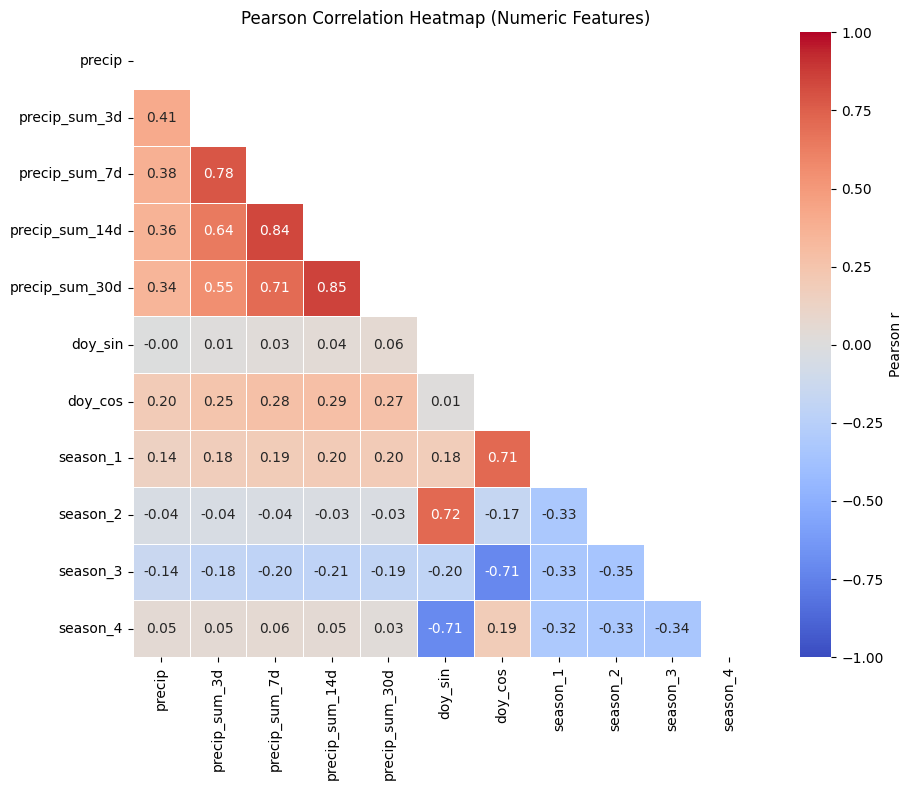

,precip,precip_sum_3d,precip_sum_7d,precip_sum_14d,precip_sum_30d,doy_sin,doy_cos,season_1,season_2,season_3,season_4
precip,1.000000,0.409446,0.378800,0.360814,0.344128,-0.000241,0.200088,0.144597,-0.044500,-0.142123,0.047726
precip_sum_3d,0.409446,1.000000,0.782734,0.644281,0.547247,0.013067,0.248368,0.175411,-0.041714,-0.180207,0.053400
precip_sum_7d,0.378800,0.782734,1.000000,0.838198,0.705525,0.025775,0.278505,0.192339,-0.036422,-0.204300,0.055939
precip_sum_14d,0.360814,0.644281,0.838198,1.000000,0.853406,0.041168,0.287422,0.196805,-0.029477,-0.209236,0.049512
precip_sum_30d,0.344128,0.547247,0.705525,0.853406,1.000000,0.060927,0.267359,0.199999,-0.029664,-0.189498,0.026342
doy_sin,-0.000241,0.013067,0.025775,0.041168,0.060927,1.000000,0.013488,0.184959,0.716102,-0.198989,-0.707419
doy_cos,0.200088,0.248368,0.278505,0.287422,0.267359,0.013488,1.000000,0.711837,-0.165564,-0.711315,0.192473
season_1,0.144597,0.175411,0.192339,0.196805,0.199999,0.184959,0.711837,1.000000,-0.327300,-0.331754,-0.316501
season_2,-0.044500,-0.041714,-0.036422,-0.029477,-0.029664,0.716102,-0.165564,-0.327300,1.000000,-0.350546,-0.334429
season_3,-0.142123,-0.180207,-0.204300,-0.209236,-0.189498,-0.198989,-0.711315,-0.331754,-0.350546,1.000000,-0.338980


In [259]:
import numpy as np

num_df = df_model.select_dtypes(include=[np.number]).copy()

# 排除 target 和 Hydro ID 相关列
exclude_cols = ["target", "target_t_plus_1d",
    "target_t_plus_3d",
    "target_t_plus_7d", "target_t_plus_1d", "target_t_plus_3d", "target_t_plus_7d"]
exclude_cols += [c for c in num_df.columns if c.startswith("HydroID_") or c == "Hydro ID"]

num_df = num_df.drop(columns=exclude_cols, errors="ignore")

corr_pearson = num_df.corr(method="pearson")
corr_pearson

# 画热力图（上三角遮罩，避免重复）
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_pearson,
    mask=mask,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson r"}
)
plt.title("Pearson Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

corr_pearson

## Modeling

### evaluate_extreme_metrics

- 先找出 y_true > q 的子集，比如 q=0.75
- 再在这个子集里看：
  - 真实值是否 > actual_threshold，比如 0.9
  - 预测值是否 > pred_threshold，比如 0.75
- 返回一些指标，比如：
  - extreme_actual_count
  - extreme_hit_count
  - extreme_hit_rate
  - r2_high_q75

In [ ]:
import numpy as np

def evaluate_extreme_metrics(y_true, y_pred, station_id, actual_q=0.9, pred_q=0.9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    station_id = np.asarray(station_id)

    if not (len(y_true) == len(y_pred) == len(station_id)):
        raise ValueError("y_true, y_pred, station_id length mismatch")

    df_eval = pd.DataFrame({
        "station_id": station_id,
        "y_true": y_true,
        "y_pred": y_pred
    })

    # Station-wise quantile thresholds
    df_eval["target_q"] = df_eval.groupby("station_id")["y_true"].transform(lambda s: s.quantile(actual_q))
    df_eval["pred_q"] = df_eval.groupby("station_id")["y_pred"].transform(lambda s: s.quantile(pred_q))

    # Quantile-based definitions
    df_eval["is_extreme_actual"] = df_eval["y_true"] > df_eval["target_q"]
    df_eval["is_extreme_pred"] = df_eval["y_pred"] > df_eval["pred_q"]
    df_eval["hit"] = df_eval["is_extreme_actual"] & df_eval["is_extreme_pred"]

    actual_cnt = int(df_eval["is_extreme_actual"].sum())
    pred_cnt = int(df_eval["is_extreme_pred"].sum())
    hit_cnt = int(df_eval["hit"].sum())

    recall = hit_cnt / actual_cnt if actual_cnt > 0 else np.nan
    precision = hit_cnt / pred_cnt if pred_cnt > 0 else np.nan

    return {
        "extreme_actual_count": actual_cnt,
        "extreme_pred_count": pred_cnt,
        "extreme_hit_count": hit_cnt,
        "extreme_hit_recall": recall,
        "extreme_precision": precision,
        "extreme_df": df_eval[df_eval["is_extreme_actual"]].reset_index(drop=True),
    }


def test_extreme_metrics_quantile_only():
    y_true = np.array([0.1, 0.2, 0.9, 0.1, 0.2, 0.8], dtype=float)
    y_pred = np.array([0.1, 0.3, 0.95, 0.1, 0.25, 0.85], dtype=float)
    station_id = np.array(["A", "A", "A", "B", "B", "B"])

    out = evaluate_extreme_metrics(y_true, y_pred, station_id, actual_q=0.9, pred_q=0.75)

    assert out["extreme_actual_count"] >= 0
    assert out["extreme_pred_count"] >= 0
    assert out["extreme_hit_count"] >= 0
    assert 0 <= out["extreme_hit_recall"] <= 1 or np.isnan(out["extreme_hit_recall"])
    assert 0 <= out["extreme_precision"] <= 1 or np.isnan(out["extreme_precision"])

In [ ]:
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

base = df_model.sort_index().copy()
all_roll = ["precip_sum_3d", "precip_sum_7d", "precip_sum_14d", "precip_sum_30d"]

configs = {
    "7d_only": ["precip_sum_7d"],
    "30d_only": ["precip_sum_30d"],
    "14d_only": ["precip_sum_14d"],
}

rows = []

for name, keep_roll in configs.items():
    drop_roll = [c for c in all_roll if c not in keep_roll]
    work = base.drop(columns=drop_roll, errors="ignore").copy()
    used_roll = [c for c in work.columns if c.startswith("precip_sum_")]
    print(name, "->", used_roll)

    X = work.drop(columns=["target"]).astype(np.float32)
    y = work["target"].astype(np.float32)

    n = len(work)
    split_idx = int(n * 0.8)

    X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

    cb = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        depth=8,
        learning_rate=0.03,
        n_estimators=4000,
        l2_leaf_reg=8,
        random_seed=42,
        od_type="Iter",
        od_wait=300,
        verbose=False
    )

    # Train without sample weighting
    cb.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

    pred_val = cb.predict(X_val)

    mse = mean_squared_error(y_val, pred_val)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, pred_val)
    mae = mean_absolute_error(y_val, pred_val)

    hydro_cols = [c for c in X_val.columns if c.startswith("HydroID_")]
    station_id_val = (
        X_val[hydro_cols]
        .idxmax(axis=1)
        .str.replace("HydroID_", "", regex=False)
        .to_numpy()
    )

    ext_metrics = evaluate_extreme_metrics(
        y_true=y_val.to_numpy(),
        y_pred=pred_val,
        station_id=station_id_val,
        actual_q=0.75,
        pred_q=0.75
    )

    used_roll = [c for c in X.columns if c.startswith("precip_sum_")]
    rows.append({
        "config": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "used_roll_features": ", ".join(used_roll),
        "extreme_actual_count": ext_metrics["extreme_actual_count"],
        "extreme_pred_count": ext_metrics["extreme_pred_count"],
        "extreme_hit_count": ext_metrics["extreme_hit_count"],
        "extreme_hit_recall": ext_metrics["extreme_hit_recall"],
        "extreme_precision": ext_metrics["extreme_precision"],
        "F1": 2 * (ext_metrics["extreme_hit_recall"] * ext_metrics["extreme_precision"]) / (ext_metrics["extreme_hit_recall"] + ext_metrics["extreme_precision"]) if not np.isnan(ext_metrics["extreme_hit_recall"]) and not np.isnan(ext_metrics["extreme_precision"]) else np.nan
    })

result = pd.DataFrame(rows).sort_values("RMSE")
print(result.to_string(index=False))

7d_only -> ['precip_sum_7d']
30d_only -> ['precip_sum_30d']
14d_only -> ['precip_sum_14d']
  config       R2      MAE     RMSE used_roll_features  extreme_actual_count  extreme_pred_count  extreme_hit_count  extreme_hit_recall  extreme_precision       F1
 7d_only 0.939922 0.020402 0.046619      precip_sum_7d                 30384               30382              27566            0.907254           0.907314 0.907284
14d_only 0.938242 0.020488 0.047266     precip_sum_14d                 30384               30383              27591            0.908077           0.908107 0.908092
30d_only 0.937021 0.020801 0.047731     precip_sum_30d                 30384               30384              27570            0.907385           0.907385 0.907385


In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
from datetime import datetime
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

base = df_model.sort_index().copy()
os.makedirs("artifacts", exist_ok=True)

all_roll = ["precip_sum_3d", "precip_sum_7d", "precip_sum_14d", "precip_sum_30d"]
target_cols = ["target", "target_t_plus_1d", "target_t_plus_3d", "target_t_plus_7d"]
horizons = {
    "t+1d": "target_t_plus_1d",
    "t+3d": "target_t_plus_3d",
    "t+7d": "target_t_plus_7d",
}

# Keep only the 7d_only feature setup
keep_roll = ["precip_sum_7d"]
drop_roll = [c for c in all_roll if c not in keep_roll]

rows = []

for hz_name, y_col in horizons.items():
    work = base.drop(columns=drop_roll, errors="ignore").copy()
    work = work.dropna(subset=[y_col]).copy()

    X = work.drop(columns=[c for c in target_cols if c in work.columns], errors="ignore").astype(np.float32)
    y = work[y_col].astype(np.float32)

    split_idx = int(len(work) * 0.8)
    X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

    cb = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        depth=8,
        learning_rate=0.03,
        n_estimators=4000,
        l2_leaf_reg=8,
        random_seed=42,
        od_type="Iter",
        od_wait=300,
        verbose=False
    )
    cb.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)
    pred_val = cb.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, pred_val))
    r2 = r2_score(y_val, pred_val)
    mae = mean_absolute_error(y_val, pred_val)

    hydro_cols = [c for c in X_val.columns if c.startswith("HydroID_")]
    station_id_val = (
        X_val[hydro_cols].idxmax(axis=1).str.replace("HydroID_", "", regex=False).to_numpy()
    )
    ext_metrics = evaluate_extreme_metrics(
        y_true=y_val.to_numpy(),
        y_pred=pred_val,
        station_id=station_id_val,
        actual_q=0.75,
        pred_q=0.75
    )

    recall = ext_metrics["extreme_hit_recall"]
    precision = ext_metrics["extreme_precision"]
    f1 = 2 * recall * precision / (recall + precision) if (
        not np.isnan(recall) and not np.isnan(precision) and (recall + precision) > 0
    ) else np.nan

    # Save one PKL per horizon
    pkl_name = f"cb_{hz_name}_7d_only.pkl".replace("+", "plus")
    bundle = {
        "model": cb,
        "mm_scaler": mm,
        "feature_columns": X.columns.tolist(),
        "horizon": hz_name,
        "target_col": y_col,
        "config": "7d_only",
        "keep_roll": keep_roll,
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }
    joblib.dump(bundle, os.path.join("artifacts", pkl_name))
    print("saved:", os.path.join("artifacts", pkl_name))

    rows.append({
        "horizon": hz_name,
        "target_col": y_col,
        "config": "7d_only",
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "extreme_actual_count": ext_metrics["extreme_actual_count"],
        "extreme_pred_count": ext_metrics["extreme_pred_count"],
        "extreme_hit_count": ext_metrics["extreme_hit_count"],
        "extreme_hit_recall": recall,
        "extreme_precision": precision,
        "F1": f1
    })

result = pd.DataFrame(rows).sort_values(["horizon", "RMSE"])
print(result.to_string(index=False))

saved: artifacts/cb_tplus1d_7d_only.pkl
saved: artifacts/cb_tplus3d_7d_only.pkl
saved: artifacts/cb_tplus7d_7d_only.pkl
horizon       target_col  config       R2      MAE     RMSE  extreme_actual_count  extreme_pred_count  extreme_hit_count  extreme_hit_recall  extreme_precision       F1
   t+1d target_t_plus_1d 7d_only 0.568041 0.085364 0.125011                 30373               30373              21298            0.701215           0.701215 0.701215
   t+3d target_t_plus_3d 7d_only 0.527210 0.089787 0.130812                 30362               30359              20481            0.674560           0.674627 0.674594
   t+7d target_t_plus_7d 7d_only 0.506232 0.092043 0.133732                 30342               30341              19862            0.654604           0.654626 0.654615
